# MiniGPT, three ways to cut text: follow along

This workbook goes with my post [MiniGPT (Part 3)](https://haddley.github.io/posts/minigpt2/). It builds the three tokenisers, checks every number in the post, trains the same machine three times, once with each tokeniser, and compares them fairly, in bits per byte.

It runs this repository's own `part3-tokenisers` scripts, so it always matches the code the post describes. In Colab, choose **Runtime → Change runtime type → GPU** first: the three training runs need a GPU. Everything before the training runs works on any runtime.

## 1. Get the code and the stories

In [1]:
import os, subprocess, sys

def run(*args):
    result = subprocess.run([sys.executable, *args], capture_output=True, text=True)
    print(result.stdout + result.stderr)
    result.check_returncode()

subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--disable-pip-version-check", "tiktoken==0.14.0", "tokenizers==0.23.2"], check=True)
if not os.path.exists("minigpt-series"):
    subprocess.run(["git", "clone", "-q", "https://github.com/Haddley/minigpt-series.git"], check=True)
os.chdir("minigpt-series/part3-tokenisers")
sys.path.insert(0, os.getcwd())
print(os.getcwd())

minigpt-series/part3-tokenisers


`prepare_data.py` downloads about 22 MB of [TinyStories](https://huggingface.co/datasets/roneneldan/TinyStories) and locks the last 10% away as the test stories.

In [2]:
run("prepare_data.py")

downloading https://huggingface.co/datasets/roneneldan/TinyStories/resolve/main/TinyStoriesV2-GPT4-valid.txt
22,493,387 characters, 22,502,601 bytes
wrote train.txt and val.txt



## 2. Three tokenisers

`tokenizers_setup.py` builds the letters tokeniser, loads GPT-2's, and trains my own 8,192-piece BPE, then prints its first fifteen glues (merges). `Ġ` stands for a space attached to the front of a piece.

In [3]:
run("tokenizers_setup.py")

char : 91 tokens
gpt2 : 50257 tokens
bpe8k: 8192 tokens
  merge  'Ġ' + 't'
  merge  'h' + 'e'
  merge  'Ġ' + 'a'
  merge  'Ġ' + 's'
  merge  'Ġ' + 'w'
  merge  'n' + 'd'
  merge  'Ġt' + 'he'
  merge  'e' + 'd'
  merge  'Ġ' + 'b'
  merge  'Ġt' + 'o'
  merge  'Ġa' + 'nd'
  merge  'Ġ' + 'h'
  merge  'Ġ' + 'f'
  merge  'Ġ' + 'T'
  merge  'i' + 'n'



The post's sentence, cut three ways:

In [4]:
from tokenizer import load_tokenizer
toks = {name: load_tokenizer(name) for name in ("char", "bpe8k", "gpt2")}
sentence = "Once upon a time, there was a little dog named Spot."
for name, tok in toks.items():
    ids = tok.encode(sentence)
    print(f"{name:6} {tok.vocab_size:>6,} token embeddings  {len(ids):>2} tokens: " + "|".join(tok.decode([i]) for i in ids))
    if name != "char":
        print(" " * 8 + "IDs:", ids)

char       91 token embeddings  52 tokens: O|n|c|e| |u|p|o|n| |a| |t|i|m|e|,| |t|h|e|r|e| |w|a|s| |a| |l|i|t|t|l|e| |d|o|g| |n|a|m|e|d| |S|p|o|t|.
bpe8k   8,192 token embeddings  13 tokens: Once| upon| a| time|,| there| was| a| little| dog| named| Spot|.
        IDs: [271, 282, 97, 240, 5, 245, 120, 97, 233, 308, 246, 422, 7]
gpt2   50,257 token embeddings  13 tokens: Once| upon| a| time|,| there| was| a| little| dog| named| Spot|.
        IDs: [7454, 2402, 257, 640, 11, 612, 373, 257, 1310, 3290, 3706, 15899, 13]


## 3. BPE by hand

The post's exercise, done in code: glue the most common neighbouring pair three times, taking the first pair when two tie.

In [5]:
from collections import Counter
pieces = list("the cat sat on the mat")
print(len(pieces), "pieces to start")
for step in range(1, 4):
    pairs = list(zip(pieces, pieces[1:]))
    counts = Counter(pairs)
    best = max(counts.values())
    a, b = next(p for p in pairs if counts[p] == best)
    glued, i = [], 0
    while i < len(pieces):
        if i + 1 < len(pieces) and (pieces[i], pieces[i + 1]) == (a, b):
            glued.append(a + b); i += 2
        else:
            glued.append(pieces[i]); i += 1
    pieces = glued
    print(f"glue {step}: {a!r} + {b!r}, {best} times -> {len(pieces)} pieces")
print(pieces)

22 pieces to start
glue 1: 'a' + 't', 3 times -> 19 pieces
glue 2: 't' + 'h', 2 times -> 17 pieces
glue 3: 'th' + 'e', 2 times -> 15 pieces
['the', ' ', 'c', 'at', ' ', 's', 'at', ' ', 'o', 'n', ' ', 'the', ' ', 'm', 'at']


## 4. What bigger pieces buy: more text per position

In [6]:
val = open("data/val.txt", encoding="utf-8").read()
val_bytes = len(val.encode("utf-8"))
for name, tok in toks.items():
    print(f"{name:6} {len(tok.encode(val)) / val_bytes:.4f} tokens per byte")

stories = [s.strip() for s in val.split("<|endoftext|>") if s.strip()]
lengths = sorted(len(s) for s in stories)
words = val.split()
print(f"\n{len(stories):,} test stories; the middle-sized one is {lengths[len(lengths) // 2]} letters long")
print(f"{len(val) / len(words):.2f} letters per word, counting its space: 256 letters is about {256 / (len(val) / len(words)):.0f} words")
story = next(s for s in stories if 900 < len(s) < 1100)
print(f"a {len(story)}-letter story needs {len(toks['bpe8k'].encode(story))} of the 256 positions with my 8k BPE")

char   0.9996 tokens per byte


bpe8k  0.2436 tokens per byte


gpt2   0.2459 tokens per byte

2,756 test stories; the middle-sized one is 722 letters long
5.07 letters per word, counting its space: 256 letters is about 50 words
a 931-letter story needs 217 of the 256 positions with my 8k BPE


## 5. What bigger pieces cost: token embeddings

In [7]:
from model import MiniGPT
for name, tok in toks.items():
    m = MiniGPT(tok.vocab_size)
    total = sum(p.numel() for p in m.parameters())
    emb = m.tok_emb.weight.numel()
    print(f"{name:6} {tok.vocab_size:>6,} embeddings: {emb:>10,} numbers in the embeddings, "
          f"{total - emb:,} in the blocks, {total / 1e6:.1f} million in all ({emb / total:.0%} embeddings)")

char       91 embeddings:     34,944 numbers in the embeddings, 10,736,640 in the blocks, 10.8 million in all (0% embeddings)


bpe8k   8,192 embeddings:  3,145,728 numbers in the embeddings, 10,736,640 in the blocks, 13.9 million in all (23% embeddings)


gpt2   50,257 embeddings: 19,298,688 numbers in the embeddings, 10,736,640 in the blocks, 30.0 million in all (64% embeddings)


## 6. The race

Train the same machine three times, 3,000 steps each, measuring bits per byte every 300 steps. On my Mac Studio's GPU, the three runs took about 15, 15, and 40 minutes. On a Colab GPU, expect them to take a similar time.

In [8]:
ITERS = 3000
for name in ("char", "bpe8k", "gpt2"):
    run("train.py", "--tokenizer", name, "--iters", str(ITERS), "--eval-interval", "300")

device mps  tokenizer char  vocab 91
train tokens 20,244,048  val tokens 2,249,339  tokens/byte 0.9996
parameters 10,771,584  (embedding 34,944, rest 10,736,640)
step     0  train 4.5089  val 4.5090  val bpb 6.5026
step   300  train 1.5975  val 1.5999  val bpb 2.3073
step   600  train 1.1876  val 1.2019  val bpb 1.7332
step   900  train 1.0125  val 1.0161  val bpb 1.4654
step  1200  train 0.9123  val 0.9254  val bpb 1.3346
step  1500  train 0.8325  val 0.8454  val bpb 1.2192
step  1800  train 0.7911  val 0.8083  val bpb 1.1656
step  2100  train 0.7595  val 0.7705  val bpb 1.1111
step  2400  train 0.7384  val 0.7517  val bpb 1.0841
step  2700  train 0.7159  val 0.7285  val bpb 1.0506
step  3000  train 0.7097  val 0.7211  val bpb 1.0400
done in 10.52 min  best val 0.7211



device mps  tokenizer bpe8k  vocab 8,192
train tokens 4,928,114  val tokens 548,149  tokens/byte 0.2436
parameters 13,882,368  (embedding 3,145,728, rest 10,736,640)
step     0  train 9.1028  val 9.1020  val bpb 3.1988
step   300  train 3.1550  val 3.1950  val bpb 1.1228
step   600  train 2.6670  val 2.7576  val bpb 0.9691
step   900  train 2.3975  val 2.4942  val bpb 0.8766
step  1200  train 2.2305  val 2.3243  val bpb 0.8169
step  1500  train 2.1087  val 2.2280  val bpb 0.7830
step  1800  train 1.9992  val 2.1407  val bpb 0.7523
step  2100  train 1.9229  val 2.0776  val bpb 0.7301
step  2400  train 1.8736  val 2.0283  val bpb 0.7128
step  2700  train 1.8388  val 2.0090  val bpb 0.7060
step  3000  train 1.8100  val 1.9825  val bpb 0.6967
done in 12.33 min  best val 1.9825



device mps  tokenizer gpt2  vocab 50,257
train tokens 4,979,415  val tokens 553,241  tokens/byte 0.2459
parameters 30,035,328  (embedding 19,298,688, rest 10,736,640)
step     0  train 10.8892  val 10.8885  val bpb 3.8622
step   300  train 3.1812  val 3.2331  val bpb 1.1468
step   600  train 2.6373  val 2.7188  val bpb 0.9644
step   900  train 2.3641  val 2.4674  val bpb 0.8752
step  1200  train 2.1878  val 2.2989  val bpb 0.8154
step  1500  train 2.0626  val 2.2014  val bpb 0.7809
step  1800  train 1.9855  val 2.1292  val bpb 0.7552
step  2100  train 1.9080  val 2.0678  val bpb 0.7335
step  2400  train 1.8494  val 2.0263  val bpb 0.7187
step  2700  train 1.8062  val 1.9807  val bpb 0.7026
step  3000  train 1.7902  val 1.9736  val bpb 0.7001
done in 41.28 min  best val 1.9736



wrote minigpt-series/part3-tokenisers/data/bpb_comparison.png

tokenizer    vocab  tok/byte       params  best step  val loss  val bpb  minutes
--------------------------------------------------------------------------------
char            91     1.000   10,771,584      3,000    0.7211   1.0400     10.5
bpe8k        8,192     0.244   13,882,368      3,000    1.9825   0.6967     12.3
gpt2        50,257     0.246   30,035,328      3,000    1.9736   0.7001     41.3



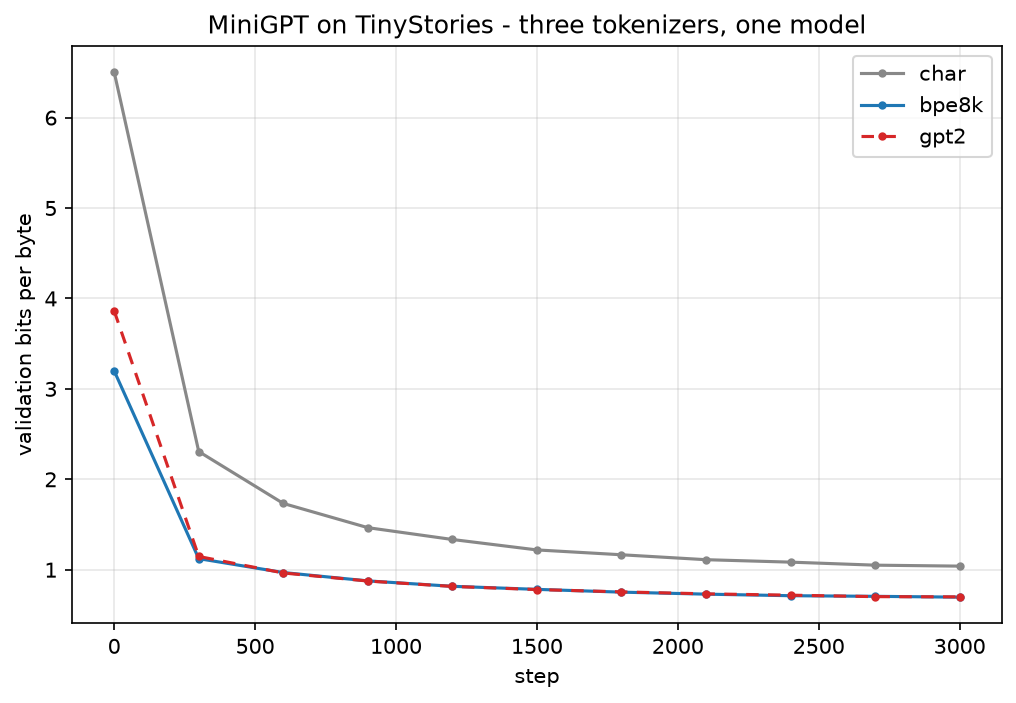

In [9]:
run("compare.py")
from IPython.display import Image, display
display(Image("data/bpb_comparison.png"))

## 7. Bits per byte, worked out

From the best checkpoint of each run: surprise per token, turned into halvings (÷ 0.693) and spread over the bytes each token covers.

In [10]:
import json, math
for name in ("char", "bpe8k", "gpt2"):
    h = json.load(open(f"data/history_{name}.json"))
    best = min(h["history"], key=lambda p: p["val"])
    bits = best["val"] / math.log(2)
    print(f"{name:6} surprise {best['val']:.4f} per token = {bits:.3f} bits per token "
          f"x {h['tokens_per_byte']:.4f} tokens per byte = {bits * h['tokens_per_byte']:.4f} bits per byte")

char   surprise 0.7211 per token = 1.040 bits per token x 0.9996 tokens per byte = 1.0400 bits per byte
bpe8k  surprise 1.9825 per token = 2.860 bits per token x 0.2436 tokens per byte = 0.6967 bits per byte
gpt2   surprise 1.9736 per token = 2.847 bits per token x 0.2459 tokens per byte = 0.7001 bits per byte


## 8. What it writes

In [11]:
for name in ("char", "bpe8k"):
    print(f"===== {name} =====")
    run("generate.py", "--tokenizer", name, "--prompt", "Once upon a time", "--max-new-tokens", "300" if name == "char" else "120")

===== char =====


checkpoint from step 3000
Once upon a time, there was a big, helpful boy named Tim. Tim wanted to mail the boy too. He said, "No, Tim! It is too hard to play with your mysterious." Tim went to look for the boy and said, "Hi, cat! We can fix it?"
They started to spin and play with the big big box. They pushed it up and pushed it up to the bo

===== bpe8k =====


checkpoint from step 3000
Once upon a time, in a big forest, there was a little bear named Bobo. Bobo was very loyal, and he loved to play all day long. He always made sure to keep the heat and safe.
One day, Bobo and his friends were playing in the forest, a bird named Chirpy. Chirpy wanted to play too, so she said to Bobo, "I can teach you to play with your friends, so you can all play together." Bobo and Chirpy were very good friends.
Bobo and Chirpy played all day. Bobo was very happy. He told Chirpy that they were friends and not his friends

